In [4]:
import pandas as pd
import numpy as np


In [5]:
from glob import glob

In [6]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
import pycountry

# Carga de datos #

In [8]:
df_happiness = pd.read_csv('../DATOS/RAW/world_happiness_combined.csv', sep=";")

El dataset fue cargado especificando sep=";" porque el archivo utiliza punto y coma como delimitador en lugar de coma, algo habitual en datasets generados con configuración regional europea.

In [9]:
df_happiness.head()

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,"7,58700","8,26132","0,96240",73,"0,99379","0,37289","0,23941",2015
1,2,Iceland,Western Europe,"7,56100","7,70416","1,00000",73,"0,93884","0,54819","0,74371",2015
2,3,Denmark,Western Europe,"7,52700","7,84114","0,97030",70,"0,96962","0,42894","0,12382",2015
3,4,Norway,Western Europe,"7,52200","8,63100","0,94917",71,"1,00000","0,43598","0,33860",2015
4,5,Canada,North America and ANZ,"7,42700","7,84595","0,94322",71,"0,94511","0,57560","0,40285",2015


In [10]:
df_happiness.columns

Index(['Ranking', 'Country', 'Regional indicator', 'Happiness score',
       'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Year'],
      dtype='object')

In [11]:
df_happiness.Ranking.nunique()

158

In [12]:
df_happiness.Country.nunique()

175

In [13]:
df_happiness.Year.unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [14]:
df_happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Ranking                       1502 non-null   int64 
 1   Country                       1502 non-null   object
 2   Regional indicator            1499 non-null   object
 3   Happiness score               1502 non-null   object
 4   GDP per capita                1502 non-null   object
 5   Social support                1502 non-null   object
 6   Healthy life expectancy       1502 non-null   int64 
 7   Freedom to make life choices  1502 non-null   object
 8   Generosity                    1502 non-null   object
 9   Perceptions of corruption     1502 non-null   object
 10  Year                          1502 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 129.2+ KB


In [15]:
df_happiness.columns = (
    df_happiness.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('.', '_', regex=False)
)
df_happiness.columns


Index(['ranking', 'country', 'regional_indicator', 'happiness_score',
       'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
       'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption', 'year'],
      dtype='object')

In [16]:
""""Cambio a variables numericas  """

columns_to_convert = ["happiness_score", 
                      "gdp_per_capita", 
                      "social_support", 
                      "freedom_to_make_life_choices", 
                      "generosity", 
                      "perceptions_of_corruption"]


def convert_to_numeric(df, columns):
    for column in columns:
        df[column] = (
            df[column]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )
        df[column] = pd.to_numeric(df[column], errors="coerce")
    
    return df

    
df_happiness = convert_to_numeric(df_happiness, columns_to_convert)



In [17]:
df_happiness.sample(10)

,ranking,country,regional_indicator,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year
474,29,Argentina,Latin America and Caribbean,6.3880,6.50476,0.65048,69,0.78637,0.10366,0.11709,2018
645,21,United Arab Emirates,Middle East and North Africa,6.8245,8.92248,0.80668,73,0.94804,0.46355,0.40133,2019
1306,82,Hong Kong S.A.R. of China,East Asia,5.3085,8.86926,0.74172,77,0.52727,0.29069,0.30460,2023
767,144,Lesotho,Sub-Saharan Africa,3.8019,2.90331,0.71999,61,0.56815,0.18977,0.20603,2019
520,79,Greece,Western Europe,5.3579,6.99674,0.69967,72,0.18072,0.00000,0.09730,2018
6,7,Netherlands,Western Europe,7.3780,7.86460,0.91295,71,0.91942,0.59821,0.42357,2015
21,22,Oman,Middle East and North Africa,6.8530,8.04603,0.77150,66,0.94476,0.27067,0.41070,2015
1046,26,Saudi Arabia,Middle East and North Africa,6.4940,8.19593,0.82245,67,0.84216,0.16719,0.70219,2021
719,96,Cameroon,Sub-Saharan Africa,5.0437,3.25968,0.56053,64,0.60354,0.33027,0.08126,2019
1418,90,Iraq,Middle East and North Africa,5.1660,5.83364,0.61610,70,0.49173,0.35251,0.08315,2024


In [18]:
df_happiness.isnull().sum()

ranking                         0
country                         0
regional_indicator              3
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
year                            0
dtype: int64

Se decide eliminar la columna regional indicator. 

In [19]:
df_happiness.dropna(subset=["regional_indicator"], inplace=True)

In [20]:
df_happiness.describe()

,ranking,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year
count,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000
mean,76.016678,5.449229,6.108579,0.691825,66.661107,0.659324,0.320469,0.453302,2019.376918
std,43.887742,1.126387,2.499286,0.212825,7.673574,0.216246,0.172597,0.321830,2.858482
min,1.000000,1.721000,0.000000,0.000000,39.000000,0.000000,0.000000,0.000000,2015.000000
25%,38.000000,4.594450,4.377775,0.564165,62.000000,0.536015,0.196170,0.158835,2017.000000
50%,76.000000,5.472000,6.304790,0.738160,68.000000,0.690750,0.296280,0.345540,2019.000000
75%,114.000000,6.282250,8.049175,0.861890,72.000000,0.832070,0.429885,0.782680,2022.000000
max,158.000000,7.842100,10.000000,1.000000,85.000000,1.000000,1.000000,1.000000,2024.000000


In [21]:
"""" creaciíon de variables en meses para poder coincidir con el dataset de clima"""

months = pd.DataFrame({'month': range(1,13)})

df_happiness= (
    df_happiness
    .merge(months, how='cross')
)

In [22]:
df_happiness.sample(10)

,ranking,country,regional_indicator,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year,month
360,31,Czech Republic,Central and Eastern Europe,6.5050,6.97451,0.86037,69,0.69228,0.13426,0.95195,2015,1
16912,85,Hong Kong,East Asia,5.3164,8.91705,0.73273,81,0.56144,0.36619,0.69833,2024,5
10265,80,Libya,Middle East and North Africa,5.4888,6.65016,0.77301,62,0.65105,0.25053,0.67691,2020,6
2319,137,Botswana,Sub-Saharan Africa,3.9740,9.97103,0.75374,58,0.72458,0.15158,0.21317,2016,4
5159,134,Burkina Faso,Sub-Saharan Africa,4.0320,1.87211,0.64777,54,0.49277,0.29933,0.25916,2017,12
11704,95,Ghana,Sub-Saharan Africa,5.0884,3.88112,0.50767,58,0.72191,0.49597,0.89369,2021,5
1135,95,Albania,Central and Eastern Europe,4.9590,5.19798,0.57361,68,0.53354,0.17933,0.88381,2015,8
1255,105,Honduras,Latin America and Caribbean,4.7880,3.52173,0.67998,64,0.59947,0.28933,0.87634,2015,8
8179,59,Honduras,Latin America and Caribbean,5.8604,3.81447,0.76135,73,0.80340,0.43420,0.17303,2019,8
11560,73,Dominican Republic,Latin America and Caribbean,5.5451,6.31987,0.75007,66,0.81207,0.18665,0.73737,2021,5


In [23]:
df_happiness.month.nunique()

12

Comprobación de creación correcta de meses 

In [24]:
df_happiness.duplicated(subset=["year"]).sum()

np.int64(17978)

In [25]:
df_happiness[df_happiness["country"] == "Turkey"]

,ranking,country,regional_indicator,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year,month
900,76,Turkey,Middle East and North Africa,5.3320,6.27647,0.67487,65,0.34066,0.15396,0.71471,2015,1
901,76,Turkey,Middle East and North Africa,5.3320,6.27647,0.67487,65,0.34066,0.15396,0.71471,2015,2
902,76,Turkey,Middle East and North Africa,5.3320,6.27647,0.67487,65,0.34066,0.15396,0.71471,2015,3
903,76,Turkey,Middle East and North Africa,5.3320,6.27647,0.67487,65,0.34066,0.15396,0.71471,2015,4
904,76,Turkey,Middle East and North Africa,5.3320,6.27647,0.67487,65,0.34066,0.15396,0.71471,2015,5
...,...,...,...,...,...,...,...,...,...,...,...,...
14503,112,Turkey,Middle East and North Africa,4.7442,7.72532,0.65551,77,0.28250,0.18641,0.19590,2022,8
14504,112,Turkey,Middle East and North Africa,4.7442,7.72532,0.65551,77,0.28250,0.18641,0.19590,2022,9
14505,112,Turkey,Middle East and North Africa,4.7442,7.72532,0.65551,77,0.28250,0.18641,0.19590,2022,10
14506,112,Turkey,Middle East and North Africa,4.7442,7.72532,0.65551,77,0.28250,0.18641,0.19590,2022,11


In [26]:
df_happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17988 entries, 0 to 17987
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ranking                       17988 non-null  int64  
 1   country                       17988 non-null  object 
 2   regional_indicator            17988 non-null  object 
 3   happiness_score               17988 non-null  float64
 4   gdp_per_capita                17988 non-null  float64
 5   social_support                17988 non-null  float64
 6   healthy_life_expectancy       17988 non-null  int64  
 7   freedom_to_make_life_choices  17988 non-null  float64
 8   generosity                    17988 non-null  float64
 9   perceptions_of_corruption     17988 non-null  float64
 10  year                          17988 non-null  int64  
 11  month                         17988 non-null  int64  
dtypes: float64(6), int64(4), object(2)
memory usage: 1.6+ MB


Verificaciones previas al merge. 

In [27]:
df_happiness["country"].value_counts()

country
Switzerland           120
Zimbabwe              120
South Africa          120
Iraq                  120
Ukraine               120
                     ... 
Djibouti               12
Congo                  12
Puerto Rico            12
State of Palestine     12
Trinidad & Tobago      12
Name: count, Length: 175, dtype: int64

In [28]:
df_happiness["month"].value_counts().sort_index()

month
1     1499
2     1499
3     1499
4     1499
5     1499
6     1499
7     1499
8     1499
9     1499
10    1499
11    1499
12    1499
Name: count, dtype: int64

In [29]:
df_happiness.duplicated(subset=["country","year","month"]).sum()

np.int64(0)

In [30]:
df_happiness.describe()

,ranking,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year,month
count,17988.000000,17988.000000,17988.000000,17988.000000,17988.000000,17988.000000,17988.000000,17988.000000,17988.000000,17988.000000
mean,76.016678,5.449229,6.108579,0.691825,66.661107,0.659324,0.320469,0.453302,2019.376918,6.500000
std,43.874320,1.126042,2.498522,0.212759,7.671227,0.216180,0.172544,0.321732,2.857608,3.452148
min,1.000000,1.721000,0.000000,0.000000,39.000000,0.000000,0.000000,0.000000,2015.000000,1.000000
25%,38.000000,4.592400,4.374160,0.564100,62.000000,0.535870,0.196000,0.158630,2017.000000,3.750000
50%,76.000000,5.472000,6.304790,0.738160,68.000000,0.690750,0.296280,0.345540,2019.000000,6.500000
75%,114.000000,6.283900,8.049870,0.862110,72.000000,0.832340,0.430200,0.782790,2022.000000,9.250000
max,158.000000,7.842100,10.000000,1.000000,85.000000,1.000000,1.000000,1.000000,2024.000000,12.000000


# Carga datos de clima: en este caso debemos cargar y unificar en un sólo fichero. 

In [31]:
df_stations = pd.read_fwf('../DATOS/RAW/ghcnd-stations.txt',
    colspecs=[(0,11),(12,20),(21,30),(31,37)],
    names=["station_id","lat","lon","country"]
)

df_stations.info()

df_stations.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129657 entries, 0 to 129656
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   station_id  129657 non-null  object 
 1   lat         129657 non-null  float64
 2   lon         129657 non-null  float64
 3   country     129657 non-null  float64
dtypes: float64(3), object(1)
memory usage: 4.0+ MB


,station_id,lat,lon,country
14389,ASN00078028,-36.1526,141.7586,110.0
22923,BR038831420,-9.0700,-38.3000,282.0
125542,USR0000MMTV,37.0711,-93.8972,376.4
44484,MXN00020202,16.7333,-96.8167,1524.9
40899,KZ000038091,44.8000,71.0670,266.0


Advertido de que con la información la columna "Country" no puedo extraer el pais, observo que en "station_id" se referecia en pais con las dos primeras letras. Se crea la columna "country_code". 

In [32]:
df_stations["country_code"] = df_stations["station_id"].str[:2]

df_stations.sample(5)

,station_id,lat,lon,country,country_code
68628,US1INDL0002,40.3353,-85.4086,270.1,US
43226,MXN00014035,20.5000,-104.7667,1266.7,MX
66469,US1IDAD0021,43.5484,-116.1337,903.7,US
93265,US1TXBZS017,30.6035,-96.2862,83.2,US
9700,ASN00048242,-30.5888,145.7890,118.0,AS


Cargo datos del clima:

In [33]:
files = glob('../DATOS/RAW/clima_10años/*.csv')

Creación de dataset de clima con sus estaciones.

In [34]:

df_clima = pd.concat(
    [pd.read_csv(f, usecols=["ID","DATE","ELEMENT","DATA_VALUE"]) for f in files],
    ignore_index=True
)

df_clima.rename(columns={"ID":"station_id", "DATA_VALUE":"value"}, inplace=True)

KeyboardInterrupt: 

In [ ]:
df_clima.sample(5)

Se deben pasar los elemenos a columnas. Usaremos sólo algunas variables climaticas, que considero interesantes para mi análisis y eso ayudará a reducir el tamaño del dataset y hacerlo más fácil de usar. 

In [ ]:
df_climate = df_clima[df_clima["ELEMENT"].isin(["TMAX","TMIN","PRCP"])]

Normalización de la fecha a datatime

In [ ]:
df_clima["DATE"] = pd.to_datetime(df_clima["DATE"].astype(str), format="%Y%m%d")

df_clima["year"] = df_clima["DATE"].dt.year
df_clima["month"] = df_clima["DATE"].dt.month



In [ ]:
df_clima.loc[df_clima["ELEMENT"].isin(["TMAX","TMIN"]), "value"] /= 10
df_clima.loc[df_clima["ELEMENT"]=="PRCP", "value"] /= 10

/var/folders/3r/zlzms3_92977hqkp2r_c_vhw0000gn/T/ipykernel_81404/873827467.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 16.8  14.8  17.4 ... -20.6 -14.4 -22.2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_clima.loc[df_clima["ELEMENT"].isin(["TMAX","TMIN"]), "value"] /= 10


In [ ]:
df_clima = df_clima.merge( df_stations,
    on="station_id",
    how="left"
)

In [ ]:
df_clima.info()

In [ ]:
df_clima.sample(5)

In [ ]:
""""Filtrar variables climaticas"""

elements_keep = [
    "TAVG",
    "TMAX",
    "TMIN",
    "PRCP",
    "SNOW",
    "SNWD",
    "AWND"
]

df_clima = df_clima[df_clima["ELEMENT"].isin(elements_keep)]

In [ ]:
df_clima.sample(10)

In [ ]:
df_clima["country_code"] = df_clima["station_id"].str[:2]

In [ ]:
df_clima = df_clima[
    [
        "station_id",
        "DATE",
        "ELEMENT",
        "value",
        "year",
        "month",
        "country_code"
    ]
]
df_clima.info()

<class 'pandas.core.frame.DataFrame'>
Index: 259723971 entries, 0 to 314689503
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   station_id    object        
 1   DATE          datetime64[ns]
 2   ELEMENT       object        
 3   value         float64       
 4   year          int32         
 5   month         int32         
 6   country_code  object        
dtypes: datetime64[ns](1), float64(1), int32(2), object(3)
memory usage: 13.5+ GB


In [ ]:
df_clima.duplicated(subset=["station_id","year","month"]).sum()

In [ ]:
df_clima.sample(5)

# Creación de columnas con las variables filtradas y pasadas a un nuevo dataset mensual: 

In [ ]:
df_clima_monthly = (
    df_clima
    .groupby(["country_code","year","month","ELEMENT"])["value"]
    .mean()
    .unstack()
    .reset_index()
)

In [ ]:
df_clima_monthly = df_clima_monthly.rename(columns={
    "TMAX":"tmax_c",
    "TMIN":"tmin_c",
    "PRCP":"precip_mm"
})

In [ ]:
""""Crear temperatura media"""

df_clima_monthly["temp_mean"] = (
    df_clima_monthly["tmax_c"] + df_clima_monthly["tmin_c"]
) / 2

creación de diccionario de paises: 

In [ ]:
df_clima_monthly.country_code.unique()

In [ ]:
""" Creación de diccionario de paises """

country_dict = {
'AE':'United Arab Emirates',
'AF':'Afghanistan',
'AG':'Algeria',
'AJ':'Azerbaijan',
'AL':'Albania',
'AM':'Armenia',
'AO':'Angola',
'AQ':'Antarctica',
'AR':'Argentina',
'AS':'Australia',
'AU':'Austria',
'AY':'Antarctica',
'BA':'Bahrain',
'BC':'Botswana',
'BD':'Bangladesh',
'BE':'Belgium',
'BF':'Bahamas',
'BG':'Bulgaria',
'BH':'Belize',
'BK':'Bosnia and Herzegovina',
'BL':'Bolivia',
'BM':'Myanmar',
'BN':'Benin',
'BO':'Belarus',
'BP':'Solomon Islands',
'BR':'Brazil',
'BU':'Bulgaria',
'BX':'Brunei',
'CA':'Canada',
'CB':'Cambodia',
'CD':'Congo (DRC)',
'CE':'Sri Lanka',
'CF':'Congo',
'CG':'Democratic Republic of the Congo',
'CH':'China',
'CI':'Chile',
'CJ':'Cayman Islands',
'CK':'Cocos Islands',
'CM':'Cameroon',
'CO':'Colombia',
'CQ':'Northern Mariana Islands',
'CS':'Costa Rica',
'CT':'Central African Republic',
'CU':'Cuba',
'CV':'Cape Verde',
'CW':'Cook Islands',
'CY':'Cyprus',
'DA':'Denmark',
'DR':'Dominican Republic',
'EC':'Ecuador',
'EG':'Egypt',
'EI':'Ireland',
'EK':'Equatorial Guinea',
'EN':'Estonia',
'ER':'Eritrea',
'ES':'El Salvador',
'ET':'Ethiopia',
'EU':'European Union',
'EZ':'Czech Republic',
'FG':'French Guiana',
'FI':'Finland',
'FJ':'Fiji',
'FK':'Falkland Islands',
'FM':'Micronesia',
'FP':'French Polynesia',
'FR':'France',
'FS':'French Southern Territories',
'GA':'Gabon',
'GB':'United Kingdom',
'GG':'Georgia',
'GH':'Ghana',
'GI':'Gibraltar',
'GL':'Greenland',
'GM':'Germany',
'GP':'Guadeloupe',
'GQ':'Guam',
'GR':'Greece',
'GV':'Guinea',
'GY':'Guyana',
'HO':'Honduras',
'HR':'Croatia',
'HU':'Hungary',
'IC':'Iceland',
'ID':'Indonesia',
'IN':'India',
'IR':'Iran',
'IS':'Israel',
'IT':'Italy',
'IV':'Ivory Coast',
'IZ':'Iraq',
'JA':'Japan',
'JM':'Jamaica',
'JN':'Jan Mayen',
'JO':'Jordan',
'JU':'Juan de Nova Island',
'KE':'Kenya',
'KG':'Kyrgyzstan',
'KN':'North Korea',
'KR':'South Korea',
'KS':'South Korea',
'KT':'Christmas Island',
'KU':'Kuwait',
'KZ':'Kazakhstan',
'LA':'Laos',
'LE':'Lebanon',
'LG':'Latvia',
'LH':'Lithuania',
'LI':'Liberia',
'LO':'Slovakia',
'LU':'Luxembourg',
'LY':'Libya',
'MA':'Morocco',
'MB':'Martinique',
'MC':'Macau',
'MD':'Moldova',
'MF':'Mayotte',
'MG':'Madagascar',
'MI':'Malawi',
'MJ':'Montenegro',
'MK':'North Macedonia',
'ML':'Mali',
'MO':'Mongolia',
'MP':'Mauritius',
'MQ':'Midway Islands',
'MR':'Mauritania',
'MT':'Malta',
'MU':'Oman',
'MV':'Maldives',
'MX':'Mexico',
'MY':'Malaysia',
'MZ':'Mozambique',
'NC':'New Caledonia',
'NE':'Niger',
'NF':'Norfolk Island',
'NG':'Nigeria',
'NH':'Vanuatu',
'NI':'Nicaragua',
'NL':'Netherlands',
'NO':'Norway',
'NP':'Nepal',
'NS':'Suriname',
'NU':'Niue',
'NZ':'New Zealand',
'PA':'Paraguay',
'PE':'Peru',
'PK':'Pakistan',
'PL':'Poland',
'PO':'Portugal',
'PP':'Papua New Guinea',
'PS':'Palau',
'PU':'Guinea-Bissau',
'QA':'Qatar',
'RE':'Reunion',
'RI':'Serbia',
'RM':'Marshall Islands',
'RO':'Romania',
'RP':'Philippines',
'RQ':'Puerto Rico',
'RS':'Russia',
'RW':'Rwanda',
'SA':'Saudi Arabia',
'SB':'Saint Pierre and Miquelon',
'SE':'Sweden',
'SF':'South Africa',
'SG':'Senegal',
'SI':'Slovenia',
'SL':'Sierra Leone',
'SN':'Singapore',
'SP':'Spain',
'SU':'Sudan',
'SV':'Svalbard',
'SW':'Switzerland',
'SX':'South Georgia and South Sandwich Islands',
'SY':'Syria',
'SZ':'Eswatini',
'TD':'Chad',
'TE':'Tonga',
'TH':'Thailand',
'TI':'Tajikistan',
'TO':'Togo',
'TS':'Tunisia',
'TU':'Turkey',
'TV':'Tuvalu',
'TX':'Turkmenistan',
'TZ':'Tanzania',
'UK':'United Kingdom',
'UP':'Ukraine',
'US':'United States',
'UV':'Burkina Faso',
'UY':'Uruguay',
'UZ':'Uzbekistan',
'VE':'Venezuela',
'VM':'Vietnam',
'VQ':'Virgin Islands',
'WA':'Namibia',
'WF':'Wallis and Futuna',
'WI':'Western Sahara',
'WQ':'Wake Island',
'WZ':'Swaziland',
'ZA':'Zambia',
'ZI':'Zimbabwe'
}

df_clima_monthly["country"] = df_clima_monthly["country_code"].map(country_dict)
        

In [ ]:
df_clima_monthly[df_clima_monthly["country"].isna()]["country_code"].unique()

array([], dtype=object)

In [ ]:
df_clima_monthly.info()

df_clima_monthly.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19838 entries, 0 to 19837
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_code    19838 non-null  object 
 1   year            19838 non-null  int32  
 2   month           19838 non-null  int32  
 3   precip_mm       19838 non-null  float64
 4   SNOW            19838 non-null  float64
 5   SNWD            19838 non-null  float64
 6   tmax_c          19838 non-null  float64
 7   tmin_c          19838 non-null  float64
 8   temp_mean       19838 non-null  float64
 9   country         19838 non-null  object 
 10  temp_range      19838 non-null  float64
 11  season          19838 non-null  object 
 12  snow_flag       19838 non-null  int64  
 13  rain_flag       19838 non-null  int64  
 14  temp_anomaly    19838 non-null  float64
 15  precip_anomaly  19838 non-null  float64
dtypes: float64(9), int32(2), int64(2), object(3)
memory usage: 2.3+ MB


ELEMENT,country_code,year,month,precip_mm,SNOW,SNWD,tmax_c,tmin_c,temp_mean,country,temp_range,season,snow_flag,rain_flag,temp_anomaly,precip_anomaly
9985,KT,2020,12,3.392584,0.0,0.000000,28.089474,22.437843,25.263658,Christmas Island,5.651631,winter,0,1,-0.074693,0.000000
10790,LO,2019,5,3.817297,0.0,11.333333,16.316935,7.126220,11.721577,Slovakia,9.190716,spring,0,1,-2.024519,1.431459
14374,PL,2018,3,0.581818,0.0,48.781818,1.992857,-6.980000,-2.493571,Poland,8.972857,spring,0,1,-6.147726,-0.421150
9235,JN,2020,6,1.333333,0.0,0.000000,5.490000,1.940000,3.715000,Jan Mayen,3.550000,summer,0,1,-0.177083,0.040417
17325,TD,2017,7,5.496552,0.0,0.000000,33.272727,23.640909,28.456818,Chad,9.631818,summer,0,1,0.238444,-1.216554


In [ ]:
df_clima_monthly.isnull().sum()

ELEMENT
country_code      0
year              0
month             0
precip_mm         0
SNOW              0
SNWD              0
tmax_c            0
tmin_c            0
temp_mean         0
country           0
temp_range        0
season            0
snow_flag         0
rain_flag         0
temp_anomaly      0
precip_anomaly    0
dtype: int64

# Tratamiento de nulos:

In [ ]:
""""Se elimina AWND debido a la elevada proporción de valores faltantes (>95%), lo que compromete la fiabilidad del análisis."""

df_clima_monthly = df_clima_monthly.drop(columns=["AWND"])

In [ ]:
""""Los valores faltantes en variables de nieve se interpretan como ausencia de nieve y se sustituyen por 0."""

df_clima_monthly["SNOW"] = df_clima_monthly["SNOW"].fillna(0)
df_clima_monthly["SNWD"] = df_clima_monthly["SNWD"].fillna(0)


In [ ]:
""""Imputación de precipitación: se utiliza la mediana por país para preservar la distribución y reducir el impacto de valores atípicos."""

df_clima_monthly["precip_mm"] = df_clima_monthly.groupby("country_code")["precip_mm"].transform(
    lambda x: x.fillna(x.median()) if x.notna().any() else x
)

df_clima_monthly["precip_mm"] = df_clima_monthly["precip_mm"].fillna(
    df_clima_monthly["precip_mm"].median()
)

In [ ]:
df_clima_monthly.groupby("country_code")["precip_mm"].apply(lambda x: x.isna().all())

country_code
AE    False
AF    False
AG    False
AJ    False
AL    False
      ...  
WI    False
WQ    False
WZ    False
ZA    False
ZI    False
Name: precip_mm, Length: 201, dtype: bool

La variable precip_mm presenta valores faltantes. Se imputan utilizando la mediana de precipitación por país, lo que permite preservar las características climáticas propias de cada región y reducir la influencia de valores extremos. En los casos en que un país no presenta registros válidos, se utiliza la mediana global del dataset.

In [ ]:
df_clima_monthly["tmax_c"] = df_clima_monthly.groupby(
    ["country_code", "month"]
)["tmax_c"].transform(
    lambda x: x.fillna(x.median()) if x.notna().any() else x
)

df_clima_monthly["tmin_c"] = df_clima_monthly.groupby(
    ["country_code", "month"]
)["tmin_c"].transform(
    lambda x: x.fillna(x.median()) if x.notna().any() else x
)

In [ ]:
df_clima_monthly["tmax_c"] = df_clima_monthly["tmax_c"].fillna(df_clima_monthly["tmax_c"].median())
df_clima_monthly["tmin_c"] = df_clima_monthly["tmin_c"].fillna(df_clima_monthly["tmin_c"].median())

In [ ]:
df_clima_monthly["temp_mean"] = (df_clima_monthly["tmax_c"] + df_clima_monthly["tmin_c"]) / 2

In [ ]:
df_clima_monthly.isnull().sum()

In [ ]:
df_clima_monthly["TAVG"] = df_clima_monthly["TAVG"].fillna(df_clima_monthly["temp_mean"])

In [ ]:
df_clima_monthly = df_clima_monthly.drop(columns="TAVG")

Creación de nuevas columnas:

In [ ]:
"""" creación de rango de temperatura """

df_clima_monthly["temp_range"] = df_clima_monthly["tmax_c"] - df_clima_monthly["tmin_c"]

In [ ]:
"""" creacicón de estacionalidad   """

def season(m):
    if m in [12,1,2]:
        return "winter"
    elif m in [3,4,5]:
        return "spring"
    elif m in [6,7,8]:
        return "summer"
    else:
        return "autumn"

df_clima_monthly["season"] = df_clima_monthly["month"].apply(season)

In [ ]:
"""""Creación de variable binaria para presencia de nieve: se asigna 1 si hay nieve (SNOW > 0) y 0 si no, facilitando análisis posteriores sobre el impacto de la nieve en la felicidad."""

df_clima_monthly["snow_flag"] = (df_clima_monthly["SNOW"] > 0).astype(int)

In [ ]:
""""creación de variable binaria para presencia de lluvia: se asigna 1 si hay precipitación (precip_mm > 0) y 0 si no, permitiendo análisis sobre la influencia de la lluvia en la felicidad."""

df_clima_monthly["rain_flag"] = (df_clima_monthly["precip_mm"] > 0).astype(int)

In [ ]:
df_clima_monthly["temp_anomaly"] = df_clima_monthly["temp_mean"] - df_clima_monthly.groupby(
    ["country_code","month"]
)["temp_mean"].transform("mean")

In [ ]:
df_clima_monthly["precip_anomaly"] = df_clima_monthly["precip_mm"] - df_clima_monthly.groupby(
    ["country_code","month"]
)["precip_mm"].transform("mean")

In [ ]:
df_clima_monthly.sample(10)

ELEMENT,country_code,year,month,precip_mm,SNOW,SNWD,tmax_c,tmin_c,temp_mean,country,temp_range,season,snow_flag,rain_flag,temp_anomaly,precip_anomaly
15479,RQ,2015,3,2.113546,0.0,0.000000,28.695910,19.149284,23.922597,Puerto Rico,9.546626,spring,0,1,-0.031352,-1.006551
13944,NZ,2016,1,2.586721,0.0,0.000000,20.695846,12.154582,16.425214,New Zealand,8.541264,winter,0,1,-1.096942,0.329099
17244,SZ,2020,2,5.269136,0.0,506.127168,8.593966,-0.243775,4.175095,Eswatini,8.837741,winter,0,1,2.111395,2.334153
12830,MY,2023,3,7.521372,0.0,0.000000,31.611043,23.742023,27.676533,Malaysia,7.869020,spring,0,1,-0.395419,1.755713
11289,MD,2015,7,2.033333,0.0,0.000000,30.480645,17.868000,24.174323,Moldova,12.612645,summer,0,1,1.170163,-7.209412
15499,RQ,2017,7,6.443104,0.0,0.000000,30.846537,22.868837,26.857687,Puerto Rico,7.977701,summer,0,1,-0.175528,1.071209
16986,SW,2023,8,4.831799,0.0,0.000000,18.909295,11.336427,15.122861,Switzerland,7.572868,summer,0,1,0.050628,2.259802
10463,LG,2017,2,4.373737,0.0,44.531532,0.320833,-4.715962,-2.197565,Latvia,5.036796,winter,0,1,-1.291638,2.585537
16398,SI,2024,7,4.156452,0.0,0.000000,22.305263,13.243750,17.774507,Slovenia,9.061513,summer,0,1,-2.599366,-0.018235
11702,MJ,2015,9,16.383333,0.0,0.000000,26.750000,14.945556,20.847778,Montenegro,11.804444,autumn,0,1,1.956256,9.460916


In [ ]:
df_clima_monthly.columns

Index(['country_code', 'year', 'month', 'precip_mm', 'SNOW', 'SNWD', 'tmax_c',
       'tmin_c', 'temp_mean', 'country', 'temp_range', 'season', 'snow_flag',
       'rain_flag', 'temp_anomaly', 'precip_anomaly'],
      dtype='object', name='ELEMENT')

In [ ]:
df_clima_monthly.duplicated(subset=["country_code","year","month"]).sum()

np.int64(0)

In [ ]:
df_clima_monthly.info()

In [ ]:
df_clima_monthly.duplicated(["country","year","month"]).sum()

np.int64(412)

In [ ]:
df_happiness.info()

In [ ]:
df_clima_monthly = df_clima_monthly.drop(columns="country_code")

El dataset climático fue agregado en dos etapas: primero a nivel mensual por estación meteorológica y posteriormente a nivel país-mes-año mediante promedios, con el objetivo de evitar duplicados durante la integración con el dataset de felicidad.

In [ ]:
df_clima_monthly.duplicated(subset=["country","year","month"]).sum()

np.int64(412)

In [ ]:
df_clima_monthly[df_clima_monthly.duplicated(subset=["country","year","month"], keep=False)].sort_values(["country","year","month"])

ELEMENT,year,month,precip_mm,SNOW,SNWD,tmax_c,tmin_c,temp_mean,country,temp_range,season,snow_flag,rain_flag,temp_anomaly,precip_anomaly
681,2015,1,22.016129,0.0,0.000000,30.664516,25.403226,28.033871,Antarctica,5.261290,winter,0,1,-0.376613,9.515645
1093,2015,1,1.379357,0.0,457.080882,-0.626620,-5.381532,-3.004076,Antarctica,4.754912,winter,0,1,-0.607100,0.018932
682,2015,2,11.085714,0.0,0.000000,31.260714,25.785714,28.523214,Antarctica,5.475000,winter,0,1,0.255105,-6.955874
1094,2015,2,1.582124,0.0,459.977099,-2.549256,-7.080062,-4.814659,Antarctica,4.530806,winter,0,1,-0.221073,0.037292
683,2015,3,5.622581,0.0,0.000000,31.258065,25.680645,28.469355,Antarctica,5.577419,spring,0,1,-0.115699,-1.300780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18402,2024,10,2.769731,0.0,0.000000,14.577656,8.146388,11.362022,United Kingdom,6.431269,autumn,0,1,0.103608,-0.838099
6905,2024,11,8.981579,0.0,0.000000,30.148148,23.218182,26.683165,United Kingdom,6.929966,autumn,0,1,-0.002860,-4.283671
18403,2024,11,2.256510,0.0,3.992021,10.588363,4.758612,7.673488,United Kingdom,5.829752,autumn,0,1,-0.018241,-0.942405
6906,2024,12,5.572941,0.0,0.000000,30.840741,23.536000,27.188370,United Kingdom,7.304741,winter,0,1,0.164781,-4.755942


In [ ]:
df_clima_monthly = df_clima_monthly.groupby(
["country","year","month"],
as_index=False
).mean(numeric_only=True)

In [ ]:
df_clima_monthly.duplicated(subset=["country","year","month"]).sum()

np.int64(0)

In [ ]:
df_clima_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19426 entries, 0 to 19425
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         19426 non-null  object 
 1   year            19426 non-null  int32  
 2   month           19426 non-null  int32  
 3   precip_mm       19426 non-null  float64
 4   SNOW            19426 non-null  float64
 5   SNWD            19426 non-null  float64
 6   tmax_c          19426 non-null  float64
 7   tmin_c          19426 non-null  float64
 8   temp_mean       19426 non-null  float64
 9   temp_range      19426 non-null  float64
 10  snow_flag       19426 non-null  float64
 11  rain_flag       19426 non-null  float64
 12  temp_anomaly    19426 non-null  float64
 13  precip_anomaly  19426 non-null  float64
dtypes: float64(11), int32(2), object(1)
memory usage: 1.9+ MB


In [ ]:
df_happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17988 entries, 0 to 17987
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ranking                       17988 non-null  int64  
 1   country                       17988 non-null  object 
 2   regional_indicator            17988 non-null  object 
 3   happiness_score               17988 non-null  float64
 4   gdp_per_capita                17988 non-null  float64
 5   social_support                17988 non-null  float64
 6   healthy_life_expectancy       17988 non-null  int64  
 7   freedom_to_make_life_choices  17988 non-null  float64
 8   generosity                    17988 non-null  float64
 9   perceptions_of_corruption     17988 non-null  float64
 10  year                          17988 non-null  int64  
 11  month                         17988 non-null  int64  
dtypes: float64(6), int64(4), object(2)
memory usage: 1.6+ MB


In [ ]:
set_h = set(zip(df_happiness.country, df_happiness.year, df_happiness.month))
set_c = set(zip(df_clima_monthly.country, df_clima_monthly.year, df_clima_monthly.month))

len(set_h - set_c)  # happiness sin clima
len(set_c - set_h)  # clima sin happiness

6041

In [ ]:
set(df_happiness.country) - set(df_clima_monthly.country)

{'Argelia',
 'Bhutan',
 'Burundi',
 'Comoros',
 'Congo (Brazzaville)',
 'Congo (Kinshasa)',
 'Czechia',
 'Djibouti',
 'Gambia',
 'Guatemala',
 'Haiti',
 'Hong Kong',
 'Hong Kong S.A.R. of China',
 'Kosovo',
 'Lesotho',
 'Macedonia',
 'North Cyprus',
 'Palestinian Territories',
 'Panama',
 'Somalia',
 'Somaliland region',
 'South Sudan',
 'State of Palestine',
 'Taiwan',
 'Taiwan Province of China',
 'Trinidad & Tobago',
 'Trinidad and Tobago',
 'Turkiye',
 'Uganda',
 'Yemen'}

In [ ]:
set(df_clima_monthly.country) - set(df_happiness.country)

{'Antarctica',
 'Bahamas',
 'Brunei',
 'Cape Verde',
 'Cayman Islands',
 'Christmas Island',
 'Cocos Islands',
 'Congo (DRC)',
 'Cook Islands',
 'Cuba',
 'Democratic Republic of the Congo',
 'Equatorial Guinea',
 'Eritrea',
 'European Union',
 'Falkland Islands',
 'Fiji',
 'French Guiana',
 'French Polynesia',
 'French Southern Territories',
 'Gibraltar',
 'Greenland',
 'Guadeloupe',
 'Guam',
 'Guinea-Bissau',
 'Guyana',
 'Jan Mayen',
 'Juan de Nova Island',
 'Macau',
 'Marshall Islands',
 'Martinique',
 'Mayotte',
 'Micronesia',
 'Midway Islands',
 'New Caledonia',
 'Niue',
 'Norfolk Island',
 'North Korea',
 'Northern Mariana Islands',
 'Palau',
 'Papua New Guinea',
 'Reunion',
 'Saint Pierre and Miquelon',
 'Solomon Islands',
 'South Georgia and South Sandwich Islands',
 'Svalbard',
 'Tonga',
 'Tuvalu',
 'Vanuatu',
 'Virgin Islands',
 'Wake Island',
 'Wallis and Futuna',
 'Western Sahara'}

In [ ]:
h_countries = set(df_happiness.country)
c_countries = set(df_clima_monthly.country)

h_countries - c_countries

{'Argelia',
 'Bhutan',
 'Burundi',
 'Comoros',
 'Congo (Brazzaville)',
 'Congo (Kinshasa)',
 'Czechia',
 'Djibouti',
 'Gambia',
 'Guatemala',
 'Haiti',
 'Hong Kong',
 'Hong Kong S.A.R. of China',
 'Kosovo',
 'Lesotho',
 'Macedonia',
 'North Cyprus',
 'Palestinian Territories',
 'Panama',
 'Somalia',
 'Somaliland region',
 'South Sudan',
 'State of Palestine',
 'Taiwan',
 'Taiwan Province of China',
 'Trinidad & Tobago',
 'Trinidad and Tobago',
 'Turkiye',
 'Uganda',
 'Yemen'}

In [ ]:
c_countries - h_countries

{'Antarctica',
 'Bahamas',
 'Brunei',
 'Cape Verde',
 'Cayman Islands',
 'Christmas Island',
 'Cocos Islands',
 'Congo (DRC)',
 'Cook Islands',
 'Cuba',
 'Democratic Republic of the Congo',
 'Equatorial Guinea',
 'Eritrea',
 'European Union',
 'Falkland Islands',
 'Fiji',
 'French Guiana',
 'French Polynesia',
 'French Southern Territories',
 'Gibraltar',
 'Greenland',
 'Guadeloupe',
 'Guam',
 'Guinea-Bissau',
 'Guyana',
 'Jan Mayen',
 'Juan de Nova Island',
 'Macau',
 'Marshall Islands',
 'Martinique',
 'Mayotte',
 'Micronesia',
 'Midway Islands',
 'New Caledonia',
 'Niue',
 'Norfolk Island',
 'North Korea',
 'Northern Mariana Islands',
 'Palau',
 'Papua New Guinea',
 'Reunion',
 'Saint Pierre and Miquelon',
 'Solomon Islands',
 'South Georgia and South Sandwich Islands',
 'Svalbard',
 'Tonga',
 'Tuvalu',
 'Vanuatu',
 'Virgin Islands',
 'Wake Island',
 'Wallis and Futuna',
 'Western Sahara'}

In [ ]:
country_map = {
    "Congo (Brazzaville)": "Congo",
    "Congo (Kinshasa)": "Democratic Republic of the Congo",
    "Czechia": "Czech Republic",
    "Macedonia": "North Macedonia",
    "Turkiye": "Turkey",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "State of Palestine": "Palestine",
    "Palestinian Territories": "Palestine"
}

df_happiness["country"] = df_happiness["country"].replace(country_map)

In [ ]:
country_map_2 = {
    "Hong Kong S.A.R. of China": "Hong Kong",
    "Taiwan Province of China": "Taiwan",
    "Trinidad & Tobago": "Trinidad and Tobago"
}

df_happiness["country"] = df_happiness["country"].replace(country_map_2)

In [ ]:
set(df_happiness.country) - set(df_clima_monthly.country)

{'Argelia',
 'Bhutan',
 'Burundi',
 'Comoros',
 'Djibouti',
 'Gambia',
 'Guatemala',
 'Haiti',
 'Hong Kong',
 'Kosovo',
 'Lesotho',
 'North Cyprus',
 'Palestine',
 'Panama',
 'Somalia',
 'Somaliland region',
 'South Sudan',
 'Taiwan',
 'Trinidad and Tobago',
 'Uganda',
 'Yemen'}

In [ ]:
# Guardar los datasets limpios para su posterior análisis y modelado.

df_clima_monthly_clean = df_clima_monthly
df_happiness_clean = df_happiness

df_happiness_clean.to_csv("../DATOS/Output/df_happiness_clean.csv", index=False)

df_clima_monthly_clean.to_csv("../DATOS/Output/df_clima_monthly_clean.csv", index=False)

In [ ]:
df_happiness["country"] = df_happiness["country"].replace(country_map)

df_final = pd.merge(
    df_happiness,
    df_clima_monthly,
    on=["country", "year", "month"],
    how="left"
)


df_final.shape

(17988, 23)

Integración de datasets
Para el análisis se integraron dos fuentes de datos:
World Happiness Dataset, que contiene indicadores de bienestar y felicidad por país.
Dataset climático, con variables meteorológicas agregadas por país, año y mes.
Dado que ambos datasets utilizan diferentes convenciones para nombrar algunos países, fue necesario realizar un proceso previo de armonización de nombres. Para ello se construyó un diccionario de equivalencias que permitió estandarizar los nombres y garantizar la correcta correspondencia entre registros.
Posteriormente se realizó la integración de los datasets mediante un merge utilizando las variables country, year y month como claves comunes.
El tipo de unión utilizado fue left join, tomando como base el dataset de felicidad. Esto permite conservar todos los registros del dataset principal e incorporar la información climática cuando está disponible.
En aquellos casos en los que no existían datos climáticos correspondientes, los valores resultantes se mantuvieron como valores nulos (NaN).
Este enfoque permite preservar la mayor cantidad de observaciones posibles del dataset principal, evitando la pérdida de información relevante para el análisis.

### El dataset final combina:

# Variables de felicidad
ranking
happiness_score
gdp_per_capita
social_support
healthy_life_expectancy
freedom_to_make_life_choices
generosity
perceptions_of_corruption


# Variables temporales
country 
year 
month


# Variables climáticas
precip_mm 
SNOW 
SNWD 
tmax_c 
tmin_c 
temp_mean 
temp_range 
snow_flag 
rain_flag 
temp_anomaly 
precip_anomaly

In [ ]:
df_final[["country","year","month"]].duplicated().sum()

np.int64(0)

In [ ]:
df_final.isna().sum()

ranking                            0
country                            0
regional_indicator                 0
happiness_score                    0
gdp_per_capita                     0
social_support                     0
healthy_life_expectancy            0
freedom_to_make_life_choices       0
generosity                         0
perceptions_of_corruption          0
year                               0
month                              0
precip_mm                       4318
SNOW                            4318
SNWD                            4318
tmax_c                          4318
tmin_c                          4318
temp_mean                       4318
temp_range                      4318
snow_flag                       4318
rain_flag                       4318
temp_anomaly                    4318
precip_anomaly                  4318
dtype: int64

In [ ]:
df_final = df_final.dropna(subset=['regional_indicator'])

In [ ]:
df_final.to_csv("../DATOS/Output/df_final.csv", index=False)

In [ ]:
df_final.columns

Index(['ranking', 'country', 'regional_indicator', 'happiness_score',
       'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
       'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption', 'year', 'month', 'precip_mm', 'SNOW',
       'SNWD', 'tmax_c', 'tmin_c', 'temp_mean', 'temp_range', 'snow_flag',
       'rain_flag', 'temp_anomaly', 'precip_anomaly'],
      dtype='object')

In [ ]:
df_final.shape
df_final.info()
df_final.describe()
df_final.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17988 entries, 0 to 17987
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ranking                       17988 non-null  int64  
 1   country                       17988 non-null  object 
 2   regional_indicator            17988 non-null  object 
 3   happiness_score               17988 non-null  float64
 4   gdp_per_capita                17988 non-null  float64
 5   social_support                17988 non-null  float64
 6   healthy_life_expectancy       17988 non-null  int64  
 7   freedom_to_make_life_choices  17988 non-null  float64
 8   generosity                    17988 non-null  float64
 9   perceptions_of_corruption     17988 non-null  float64
 10  year                          17988 non-null  int64  
 11  month                         17988 non-null  int64  
 12  precip_mm                     13670 non-null  float64
 13  S

ranking                            0
country                            0
regional_indicator                 0
happiness_score                    0
gdp_per_capita                     0
social_support                     0
healthy_life_expectancy            0
freedom_to_make_life_choices       0
generosity                         0
perceptions_of_corruption          0
year                               0
month                              0
precip_mm                       4318
SNOW                            4318
SNWD                            4318
tmax_c                          4318
tmin_c                          4318
temp_mean                       4318
temp_range                      4318
snow_flag                       4318
rain_flag                       4318
temp_anomaly                    4318
precip_anomaly                  4318
dtype: int64

In [ ]:
df_final[df_final['temp_mean'].isnull()][['country','year','month']].head(20)

,country,year,month
288,Panama,2015,1
289,Panama,2015,2
290,Panama,2015,3
291,Panama,2015,4
292,Panama,2015,5
293,Panama,2015,6
294,Panama,2015,7
295,Panama,2015,8
296,Panama,2015,9
297,Panama,2015,10


In [ ]:
df_final[df_final['temp_mean'].isnull()]['country'].value_counts().head(10)

country
Panama       120
Uganda       120
Guatemala    120
Kosovo       120
Hong Kong    120
Taiwan       120
Palestine    108
Yemen        108
Niger        104
Argelia       96
Name: count, dtype: int64

La falta de datos climáticos en determinados países pone de manifiesto las limitaciones estructurales de los datasets globales y su posible sesgo geográfico.

In [ ]:
cols_clima = [
    'precip_mm', 'SNOW', 'SNWD', 'tmax_c', 'tmin_c',
    'temp_mean', 'temp_range', 'snow_flag',
    'rain_flag', 'temp_anomaly', 'precip_anomaly'
]

df_final = df_final.dropna(subset=cols_clima)

In [ ]:
df_final.isnull().sum()


ranking                         0
country                         0
regional_indicator              0
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
year                            0
month                           0
precip_mm                       0
SNOW                            0
SNWD                            0
tmax_c                          0
tmin_c                          0
temp_mean                       0
temp_range                      0
snow_flag                       0
rain_flag                       0
temp_anomaly                    0
precip_anomaly                  0
dtype: int64

In [ ]:
df_final.shape

(13670, 23)

Durante el proceso de integración de datos se detectaron valores nulos en las variables climáticas.
El análisis mostró que estos nulos no eran aleatorios, sino que correspondían a países completos sin información climática disponible en la fuente utilizada (por ejemplo, Panamá, Uganda o Kosovo).
Dado que no existía información histórica suficiente para estos países, se descartó la imputación de valores para evitar la introducción de sesgos.
En consecuencia, se procedió a eliminar dichos registros, garantizando así la consistencia y fiabilidad del análisis posterior.

# Análisis de varibles únicas

<Axes: xlabel='happiness_score', ylabel='Count'>

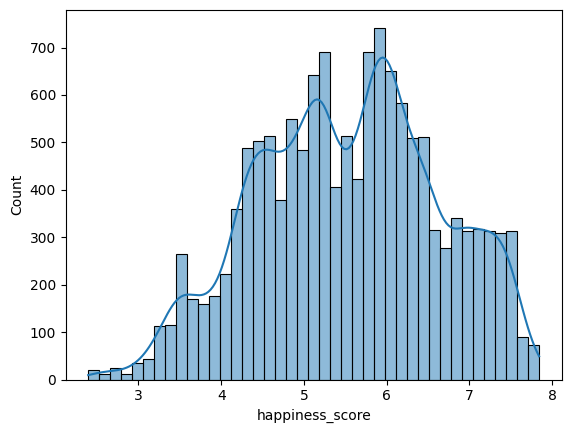

In [ ]:
# Felicidad 

sns.histplot(df_final['happiness_score'], kde=True)

<Axes: xlabel='temp_mean', ylabel='Count'>

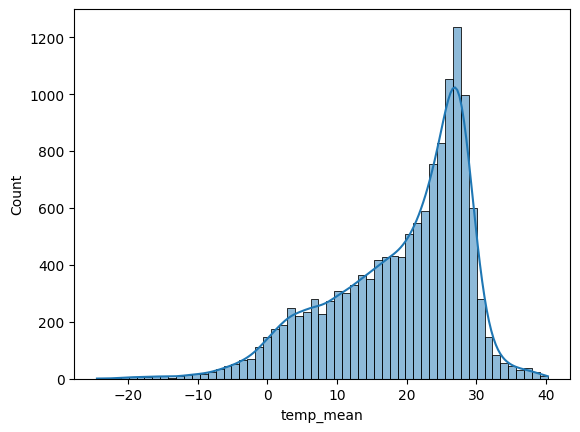

In [ ]:
# Temperatura 

sns.histplot(df_final['temp_mean'], kde=True)

<Axes: xlabel='precip_mm', ylabel='Count'>

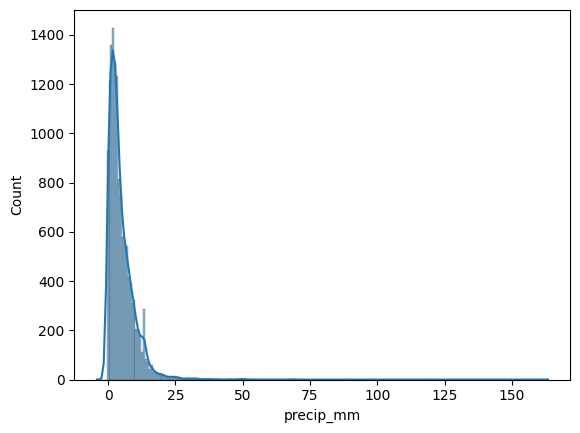

In [ ]:
# Precipitación

sns.histplot(df_final['precip_mm'], kde=True)

# Análisis por país / región

In [ ]:
# Top países más felices

df_final.groupby('country')['happiness_score'].mean().sort_values(ascending=False).head(10)

country
Finland        7.693937
Denmark        7.586446
Iceland        7.526602
Switzerland    7.442251
Norway         7.441568
Netherlands    7.409646
Sweden         7.350298
Israel         7.259771
New Zealand    7.236258
Australia      7.196690
Name: happiness_score, dtype: float64

In [ ]:
# Región: 

df_final.groupby('regional_indicator')['happiness_score'].mean().sort_values(ascending=False).head(10)

regional_indicator
North America and ANZ                 7.136069
Western Europe                        6.798582
Latin America and Caribbean           6.040665
Central and Eastern Europe            5.755165
East Asia                             5.595506
Southeast Asia                        5.425402
Commonwealth of Independent States    5.374984
Middle East and North Africa          5.345074
South Asia                            4.467990
Sub-Saharan Africa                    4.367847
Name: happiness_score, dtype: float64

<Axes: xlabel='year'>

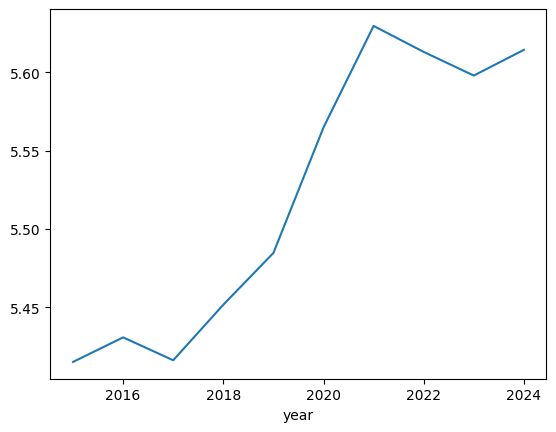

In [ ]:
# Análisis temporal 

df_final.groupby('year')['happiness_score'].mean().plot()

<Axes: xlabel='month'>

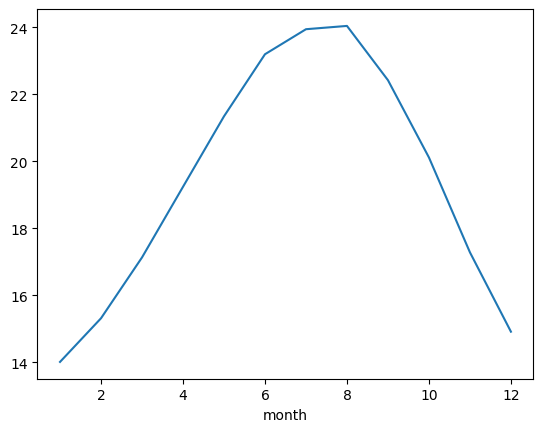

In [ ]:
df_final.groupby('month')['temp_mean'].mean().plot()

<Axes: xlabel='temp_mean', ylabel='happiness_score'>

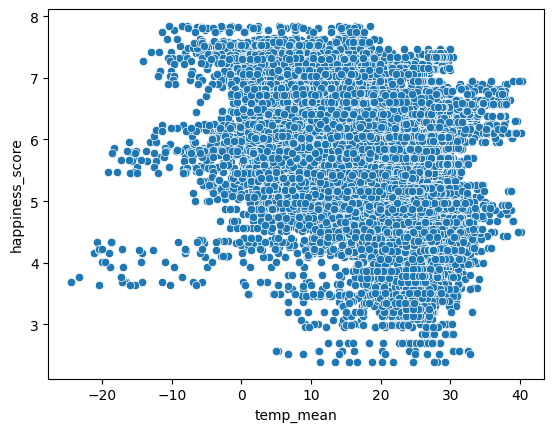

In [ ]:
# Temperatura vs. Felicidad

sns.scatterplot(x='temp_mean', y='happiness_score', data=df_final)

<Axes: xlabel='rain_flag', ylabel='happiness_score'>

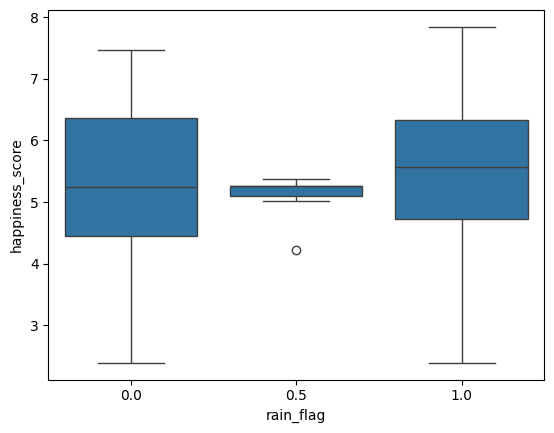

In [ ]:
#Lluvia vs. Felicidad

sns.boxplot(x='rain_flag', y='happiness_score', data=df_final)

<Axes: xlabel='snow_flag', ylabel='happiness_score'>

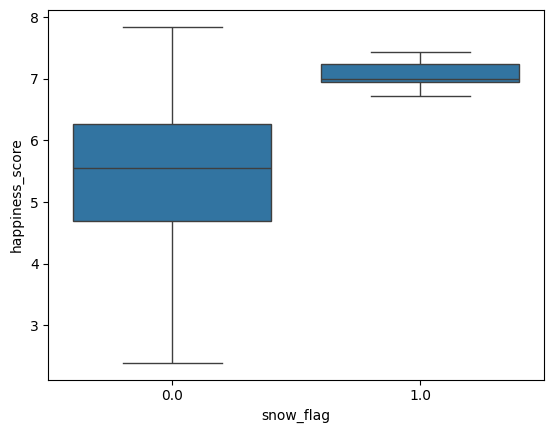

In [ ]:
# Nieve vs. Felicidad

sns.boxplot(x='snow_flag', y='happiness_score', data=df_final)

<Axes: >

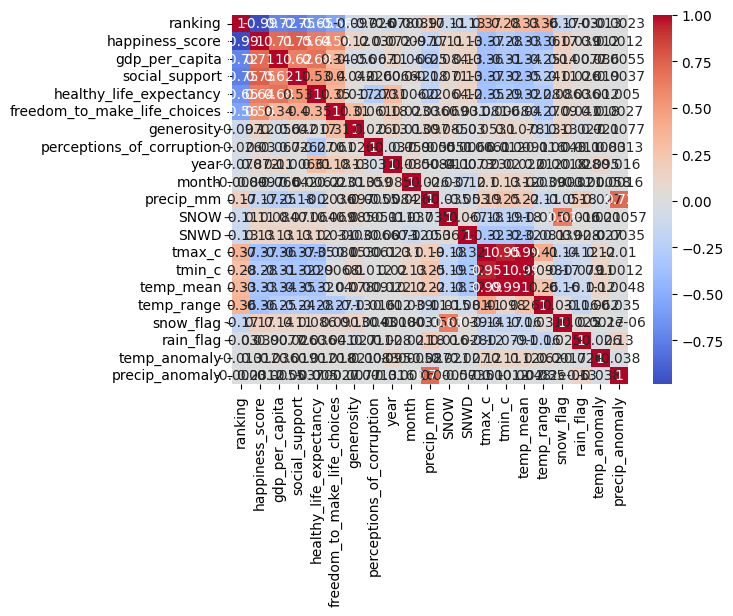

In [ ]:
corr = df_final.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

El clima tiene una influencia limitada sobre la felicidad en comparación con factores estructurales como el nivel económico o el bienestar social.

Las variables de temperatura son redundantes (miden lo mismo en esencia)

Las desviaciones climáticas puntuales no parecen impactar significativamente en el bienestar percibido.

La percepción de libertad individual también juega un papel relevante en la felicidad.

El análisis de correlación revela que la felicidad presenta una fuerte relación con variables socioeconómicas como el PIB per cápita, el apoyo social y la esperanza de vida saludable.
En contraste, las variables climáticas, como la temperatura media o la precipitación, muestran correlaciones débiles, lo que sugiere que su impacto sobre la felicidad es limitado.
Asimismo, las anomalías climáticas no parecen influir de manera significativa en el bienestar percibido.
Estos resultados indican que la felicidad es un fenómeno multifactorial, donde los factores estructurales tienen un peso considerablemente mayor que las condiciones climáticas.

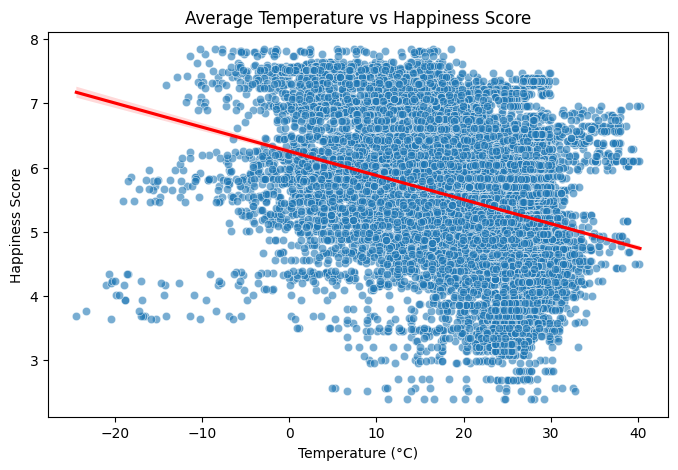

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='temp_mean',
    y='happiness_score',
    data=df_final,
    alpha=0.6
)

sns.regplot(
    x='temp_mean',
    y='happiness_score',
    data=df_final,
    scatter=False,
    color='red'
)

plt.title('Average Temperature vs Happiness Score')
plt.xlabel('Temperature (°C)')
plt.ylabel('Happiness Score')

plt.show()

<Axes: xlabel='gdp_per_capita', ylabel='happiness_score'>

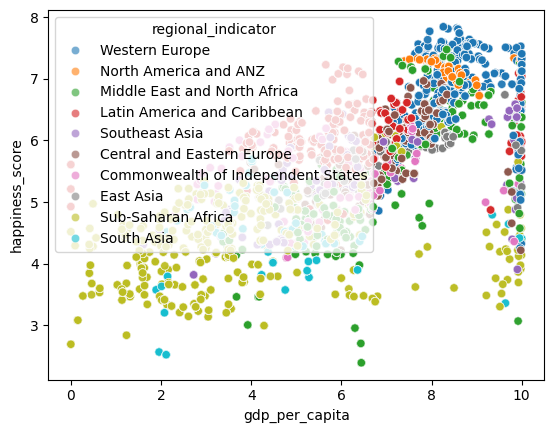

In [ ]:
sns.scatterplot(
    x='gdp_per_capita',
    y='happiness_score',
    hue='regional_indicator',
    data=df_final,
    alpha=0.6
)

<Axes: xlabel='temp_mean'>

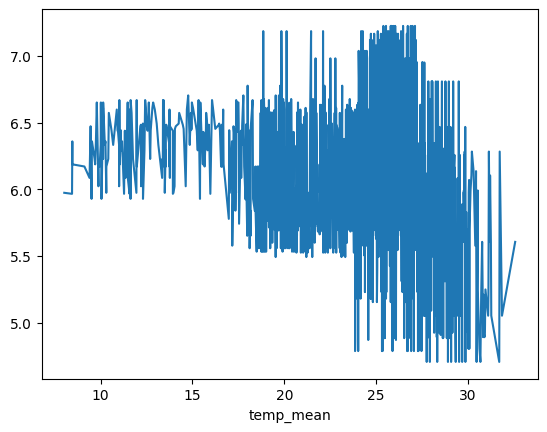

In [ ]:
# comparación de niveles de felicidad vs clima en Latinoamérica

df_final[df_final['regional_indicator'] == 'Latin America and Caribbean'].groupby('temp_mean')['happiness_score'].mean().plot()

<Axes: xlabel='temp_mean'>

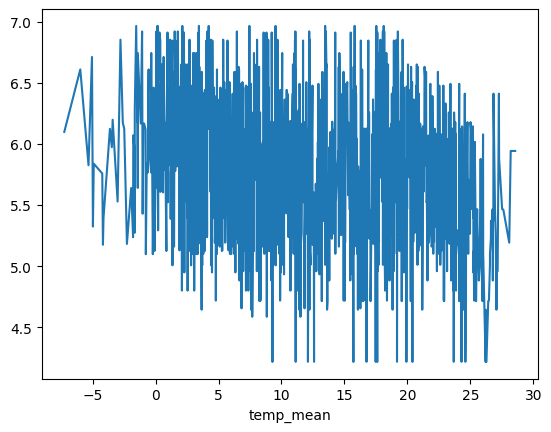

In [ ]:
df_final[df_final['regional_indicator'] == 'Central and Eastern Europe'].groupby('temp_mean')['happiness_score'].mean().plot()

En Paises de bajos ingresos si que se nota una diferencia y mayor impacto de la situación climatica en los niveles de felicidad

Ampliación de Dataset : 

In [ ]:
scenarios = {
    'normal': 0,
    'heat': 2,
    'cold': -2
}

df_expanded = pd.concat([
    df_final.assign(
        scenario=key,
        temp_mean=df_final['temp_mean'] + val
    )
    for key, val in scenarios.items()
])

In [ ]:
df_expanded.shape

(41010, 24)

<Axes: xlabel='scenario', ylabel='happiness_score'>

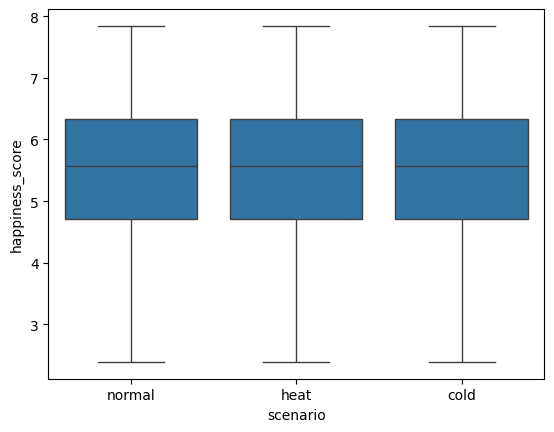

In [ ]:
sns.boxplot(x='scenario', y='happiness_score', data=df_expanded)